In [4]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

In [6]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, seq_len_q, d_k)
    K: (batch, seq_len_k, d_k)
    V: (batch, seq_len_k, d_v)
    mask: broadcast to (batch, seq_len_q, seq_len_k)

    Returns:
        output: (batch, seq_len_q, d_v)
        weights: (batch, seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)

    # 1) relevant score, dimesion: (batch, seq_len_q, seq_len_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) 
    # 2) scale
    scores = scores / math.sqrt(d_k)
    # 3) mask
    if mask is not None:
        scores = scores.masked_fill(mask==0, float('-inf'))
    #4) Softmax -> attention weights
    weights = F.softmax(scores, dim=-1)
    #5) output: weighted sum from values
    output = torch.matmul(weights, V)
    return output, weights
        
batch_size, seq_len, d_k = 2, 4, 8
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Row sum: {weights.sum(-1)}")
    

Output shape: torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])
Row sum: tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])


In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        
        Q = self.W_Q(Q) #(B, seq, d_model)
        K = self.W_K(K)
        V = self.W_V(V)

        # get different heads, (B, seq, d_model) -> (B, seq, num_heads, d_k) -> (B, num_heads, seq, d_k)
        Q = Q.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)

        d_k = Q.size(-1)
        
        scores = torch.matmul(Q, K.transpose(-2, -1))
        print(f"scores dimension: {scores.shape}")
        if mask != None:
            scores.mask_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim= -1)
        print(f"Attention weight dimension: {attn_weights.shape}")
        
        # score (B, num_heads, seq, seq), V (B, num_heads, seq, d_k)
        # context (B, num_heads, seq, d_k)
        context = torch.matmul(scores, V)
        # (B, num_heads, seq, d_k) -> (B, seq, num_heads, d_k) -> (B, seq, d_model)
        context = context.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        # 加一个线性层，让不同head叠加
        output = self.W_O(context)
        print(f"Output dimension: {output.shape}")
        return output, attn_weights

d_model, num_heads = 512, 8
mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(2, 10, d_model)
output, attn = mha(x, x, x)
print(f"\nOutput: {output.shape}")
print(f"Attention weights: {attn.shape}")
        
        
        

scores dimension: torch.Size([2, 8, 10, 10])
Attention weight dimension: torch.Size([2, 8, 10, 10])
Output dimension: torch.Size([2, 10, 512])

Output: torch.Size([2, 10, 512])
Attention weights: torch.Size([2, 8, 10, 10])


In [17]:
print(output[0,0,1])
print(output[0,0,1].dtype)
print(type(output[0, 0, 1]))

tensor(2.9701, grad_fn=<SelectBackward0>)
torch.float32
<class 'torch.Tensor'>


In [20]:
def create_padding_mask(seq, pad_idx=0):
    """
    seq: (batch, seq_len) - token indices
    return: (batch, 1, 1, seq_len)
    """
    mask = (seq != pad_idx).unsqueeze(1).unsqueeze(2)
    return mask

sequences = torch.tensor([
    [5, 3, 7, 2, 0, 0],  # 后两个是 padding
    [1, 4, 6, 0, 0, 0],  # 后三个是 padding
])
pad_mask = create_padding_mask(sequences)
print(type(pad_mask))
print(pad_mask.shape)
print(pad_mask[0])


    

<class 'torch.Tensor'>
torch.Size([2, 1, 1, 6])
tensor([[[ True,  True,  True,  True, False, False]]])


In [21]:
def create_causal_mask(seq_len):
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask.unsqueeze(0).unsqueeze(0)

causal = create_causal_mask(4)
print(causal[0][0])

tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])


In [22]:
combined = pad_mask & create_causal_mask(seq_len).bool()

RuntimeError: The size of tensor a (6) must match the size of tensor b (4) at non-singleton dimension 3

In [23]:
Q = torch.tensor([[1., 0., 1.],   # query 位置 0
                   [0., 1., 0.]])   # query 位置 1

K = torch.tensor([[1., 1., 0.],   # key 位置 0
                   [0., 0., 1.]])   # key 位置 1

V = torch.tensor([[1., 2., 3.],   # value 位置 0
                   [4., 5., 6.]])   # value 位置 1

# Step 1: Q @ K^T
scores = Q @ K.T
print("Raw scores:", scores)
# [[1*1+0*1+1*0, 1*0+0*0+1*1],   = [[1, 1],
#  [0*1+1*1+0*0, 0*0+1*0+0*1]]     [1, 0]]

# Step 2: Scale
scaled = scores / math.sqrt(3)  # sqrt(d_k) = sqrt(3) ≈ 1.732
print("Scaled:", scaled)

# Step 3: Softmax
weights = F.softmax(scaled, dim=-1)
print("Weights:", weights)
# Row 0: scores 相等 → 接近 [0.5, 0.5]
# Row 1: [1, 0] → 更偏向位置 0

# Step 4: 加权求和
output = weights @ V
print("Output:", output)
# 位置 0 ≈ 0.5*[1,2,3] + 0.5*[4,5,6] = [2.5, 3.5, 4.5]
# 位置 1 → 更偏向 V[0]

print("\n✅ 每一步 shape 和数值都对上了")

Raw scores: tensor([[1., 1.],
        [1., 0.]])
Scaled: tensor([[0.5774, 0.5774],
        [0.5774, 0.0000]])
Weights: tensor([[0.5000, 0.5000],
        [0.6405, 0.3595]])
Output: tensor([[2.5000, 3.5000, 4.5000],
        [2.0786, 3.0786, 4.0786]])

✅ 每一步 shape 和数值都对上了


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_attention(attn_weights, tokens, head_idx=0):
    """
    attn_weights: (batch, num_heads, seq_len, seq_len)
    tokens: list of token strings
    """
    attn = attn_weights[0, head_idx].detach().numpy()

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(attn, cmap='Blues')

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticklabels(tokens)

    for i in range(len(tokens)):
        for j in range(len(tokens)):
            ax.text(j, i, f'{attn[i,j]:.2f}',
                    ha='center', va='center', fontsize=8)

    ax.set_xlabel('Key (被关注的词)')
    ax.set_ylabel('Query (当前词)')
    ax.set_title(f'Attention Weights — Head {head_idx}')
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=150)
    plt.show()

scores dimension: torch.Size([1, 4, 6, 6])
Attention weight dimension: torch.Size([1, 4, 6, 6])
Output dimension: torch.Size([1, 6, 64])


/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96

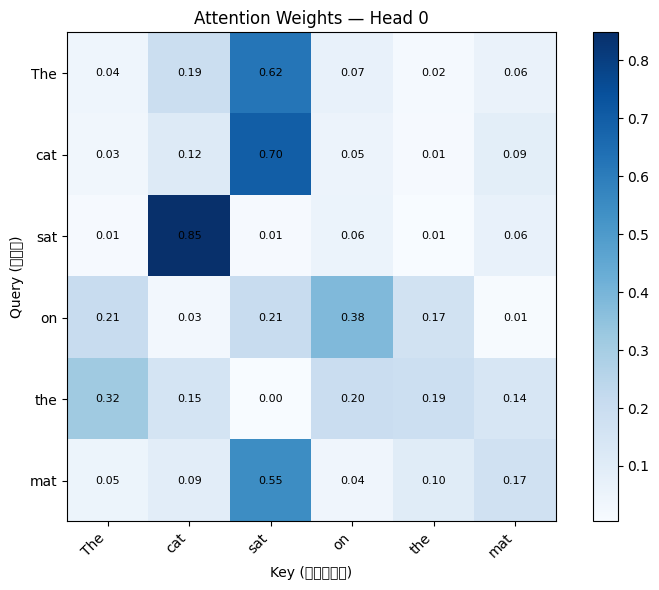

/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96

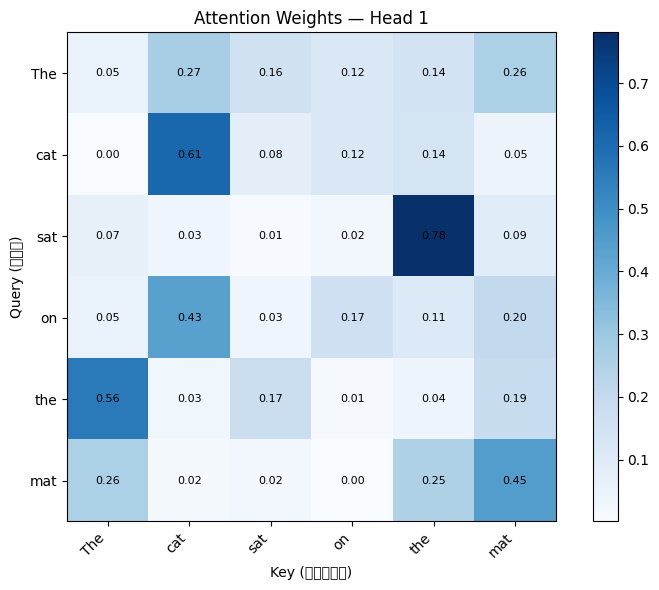

/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96

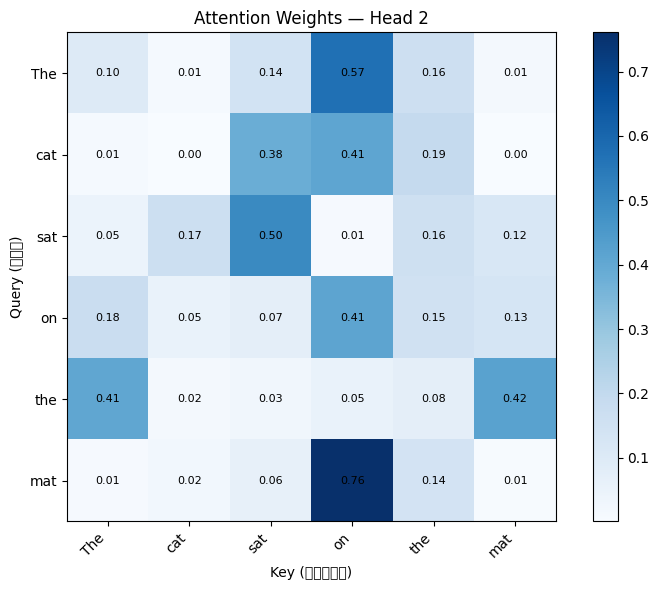

/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96n59n_r581hvt3_w0000gn/T/ipykernel_55558/479687045.py:28: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/x5/9dx202x96

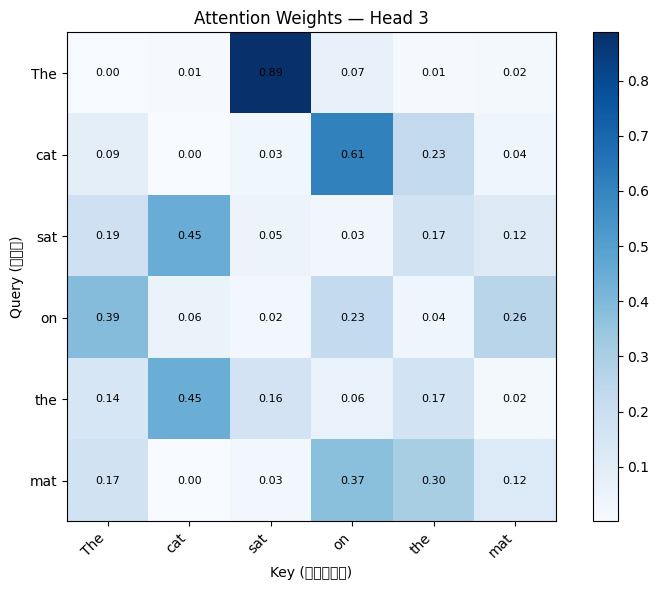

In [25]:
tokens = ["The", "cat", "sat", "on", "the", "mat"]
d_model, num_heads = 64, 4

mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(1, len(tokens), d_model)
output, attn_weights = mha(x, x, x)

# 看每个 head 的不同 pattern
for h in range(num_heads):
    visualize_attention(attn_weights, tokens, head_idx=h)

# 观察：不同 head 的 pattern 不同
# 训练后会看到有意义的语法/语义关系